In [25]:
import polars as pl
import polars.selectors as cs
from hta.trace_analysis import TraceAnalysis
import pandas as pd
import glob
import os

In [26]:
power_labels = [
    "IBP,",        "ICP,",        "DCP,",      "TCP,",      "CCP,",
    "SHRDP,",      "RFP,",        "INTP,",     "FPUP,",     "DPUP,",
    "INT_MUL24P,", "INT_MUL32P,", "INT_MULP,", "INT_DIVP,", "FP_MULP,",
    "FP_DIVP,",    "FP_SQRTP,",   "FP_LGP,",   "FP_SINP,",  "FP_EXP,",
    "DP_MULP,",    "DP_DIVP,",    "TENSORP,",  "TEXP,",     "SCHEDP,",
    "L2CP,",       "MCP,",        "NOCP,",     "DRAMP,",    "PIPEP,",
    "IDLE_COREP,", "CONSTP",      "STATICP"
]

In [27]:
df = (
    pl.scan_csv(
        "/users/zarand1a/accel-sim-framework/sim_run_12.8/*/NO_ARGS/QV100-Accelwattch_SASS_SIM/accelwattch_power_report.log", 
        has_header=False, 
        separator="?", 
        include_file_paths="path",
    )
    .select(
        pl.col("path").str.extract(r"sim_run_12.8/([^/]*)/.*/accelwattch_power_report.log")
        .alias("benchmark"),
        pl.col("column_1").alias("data")
    )
    .with_row_index()
    .collect()
)
df

index,benchmark,data
u32,str,str
0,"""bert""","""kernel_name = _ZN2at6native44_…"
1,"""bert""","""kernel_launch_uid = 1 """
2,"""bert""",null
3,"""bert""","""Kernel Average Power Data:"""
4,"""bert""","""kernel_avg_power = 56.8932"""
…,…,…
1876009,"""resnet50-train""","""gpu_tot_avg_power = 95.5163"""
1876010,"""resnet50-train""","""gpu_tot_max_power = 253.477"""
1876011,"""resnet50-train""","""gpu_tot_min_power = 55.4642"""


In [28]:
power_df = (
    (
        df.filter(pl.col("data").str.starts_with("gpu_avg_"))
        .select(
            "index",
            pl.col("data")
            .str.replace("^gpu_avg_", "")
            .str.replace_all(" ", "")
            .str.splitn("=", 2)
            .struct.rename_fields(["label", "value"])
            .struct.with_fields(pl.field("value").cast(float))
            .struct.unnest()
        )
    )
    .join_asof(
        df.filter(pl.col("data").str.starts_with("kernel_name"))
        .select(
            pl.col("index"),
            pl.col("index").rank("dense").over("benchmark").alias("serial"),
            pl.col("benchmark"),
            pl.col("data").str.extract("kernel_name = (.*)").alias("kernel")
        ),
        on="index",
    )
    .drop("index")
    .group_by("benchmark", "serial", "kernel", "label").agg(pl.mean("value"))
    .pivot(on="label", index=["benchmark", "serial", "kernel"])
    .select("benchmark", "serial", "kernel", *power_labels)
    .with_columns(
        pl.col("DRAMP,") + pl.col("MCP,"),
        pl.col("L2CP,") + pl.col("NOCP,"),
    )
    .rename(lambda col: col.replace(",", ""))
    .unpivot(index=["benchmark", "serial", "kernel"], value_name="power_w")
    .group_by("benchmark", "serial", "kernel")
    .agg(pl.sum("power_w"))
    .sort("benchmark", "serial", "kernel")
)
power_df

benchmark,serial,kernel,power_w
str,u32,str,f64
"""bert""",1,"""_ZN2at6native44_GLOBAL__N__50c…",57.490228
"""bert""",2,"""_ZN2at6native44_GLOBAL__N__50c…",57.322012
"""bert""",3,"""_ZN2at6native29vectorized_elem…",56.733263
"""bert""",4,"""_ZN2at6native44_GLOBAL__N__50c…",57.496691
"""bert""",5,"""_ZN2at6native29vectorized_elem…",56.42046
…,…,…,…
"""resnet50-train""",941,"""_ZN2at6native57_GLOBAL__N__e65…",69.95192
"""resnet50-train""",942,"""_ZN2at6native54_GLOBAL__N__f8a…",84.832087
"""resnet50-train""",943,"""_ZN2at6native54_GLOBAL__N__f8a…",100.542158


In [29]:
df = (
    pl.scan_csv("/users/zarand1a/accel-sim-framework/sim_run_12.8/*/NO_ARGS/QV100-Accelwattch_SASS_SIM/*-NO_ARGS.*",
        has_header=False, 
        separator="&", 
        include_file_paths="path",
    )
    .select(
        pl.col("path").str.extract(r"sim_run_12.8/([^/]*)/.*")
        .alias("benchmark"),
        pl.col("column_1").alias("data")
    )
    .with_row_index()
    .collect()
)
df

index,benchmark,data
u32,str,str
0,"""bert""","""Skipping setup_environment - a…"
1,"""bert""","""doing: export -n PTX_SIM_USE_P…"
2,"""bert""","""doing: export LD_LIBRARY_PATH=…"
3,"""bert""","""doing: cd /users/zarand1a/acce…"
4,"""bert""","""doing: export OPENCL_CURRENT_T…"
…,…,…
23143918,"""resnet50-train""","""gpgpu_simulation_rate = 230813…"
23143919,"""resnet50-train""","""gpgpu_simulation_rate = 185 (c…"
23143920,"""resnet50-train""","""gpgpu_silicon_slowdown = 61189…"


In [30]:
cycle_df = (
    df.filter(pl.col("data").str.starts_with("kernel_name ="))
    .select(
        "index", "benchmark",
        pl.col("data").str.extract("kernel_name = (.*)").alias("kernel"),
    )
).join(
    df.filter(pl.col("data").str.starts_with("gpu_sim_cycle ="))
    .select(
        pl.col("index") - 3,
        pl.col("data").str.extract("gpu_sim_cycle = (.*)").cast(int).alias("cycle"),
    ),
    on="index",
).select(
    "benchmark",
    pl.col("index").rank("dense").over("benchmark").alias("serial"),
    "kernel", "cycle",
)
cycle_df.write_csv("kernel_times2.csv")

In [31]:
import subprocess

def demangle_name(
    df: pl.DataFrame,
    mangled_col: str,
    new_col_name: str = "demangled_name"
) -> pl.DataFrame:
    """
    Demangles C++ symbols in a Polars DataFrame column using cu++filt.

    Args:
        df: The input Polars DataFrame.
        mangled_col: The name of the column containing mangled symbols.
        new_col_name: The name for the new column with demangled symbols.

    Returns:
        A new DataFrame with the added demangled column.
    """
    if mangled_col not in df.columns:
        raise ValueError(f"Column '{mangled_col}' not found in the DataFrame.")

    # 1. Extract all mangled names into a list
    mangled_names: list[str] = df[mangled_col].to_list()

    if not mangled_names:
        # Handle empty DataFrame case
        return df.with_columns(pl.lit(None, dtype=pl.String).alias(new_col_name))

    # 2. Join names with newlines for batch processing via stdin
    input_text = "\n".join(mangled_names)
    demangled_names: list[str] = []

    # 3. Execute cu++filt in a single batch call
    command = ['/usr/local/cuda/bin/cu++filt']
    result = subprocess.run(
        command,
        input=input_text,
        capture_output=True,
        text=True,
        check=True
    )
    demangled_names = result.stdout.strip().split('\n')
    
    # 4. Basic sanity check
    if len(mangled_names) != len(demangled_names):
        raise RuntimeError("Mismatch between number of input and output names.")

    # 5. Add the demangled names as a new column to the DataFrame
    return df.with_columns(pl.Series(name=new_col_name, values=demangled_names))

In [24]:
demangle_name(cycle_df, "kernel", "kernel_demangled").write_csv("kernel_times.csv")

In [21]:
cycle_df

benchmark,serial,kernel,cycle
str,u32,str,i64
"""bert""",1,"""_ZN2at6native44_GLOBAL__N__50c…",10376
"""bert""",2,"""_ZN2at6native44_GLOBAL__N__50c…",8566
"""bert""",3,"""_ZN2at6native29vectorized_elem…",5772
"""bert""",4,"""_ZN2at6native44_GLOBAL__N__50c…",10402
"""bert""",5,"""_ZN2at6native29vectorized_elem…",5772
…,…,…,…
"""resnet50-train""",941,"""_ZN2at6native57_GLOBAL__N__e65…",23800
"""resnet50-train""",942,"""_ZN2at6native54_GLOBAL__N__f8a…",50736
"""resnet50-train""",943,"""_ZN2at6native54_GLOBAL__N__f8a…",172263


In [7]:
accel_df = (
    power_df.join(cycle_df, on=["benchmark", "serial", "kernel"])
    .filter(pl.col("power_w").is_not_nan())
    .group_by("benchmark")
    .agg(
        power_w=(pl.col("power_w") * pl.col("cycle")).sum() / pl.col("cycle").sum(),
        cycles=pl.col("cycle").sum()
    )
)

In [8]:
df = (
    pl.scan_csv(
        "/proj/threadtune-PG0/amir/power_logs/*-power.0.csv", 
        include_file_paths="path",
    )
    .with_columns(
        pl.col("path").str.extract(r"/proj/threadtune-PG0/amir/power_logs/(.*)-power.0.csv")
        .alias("benchmark"),
    )
    .drop("path")
    .collect()
)

In [16]:
measure_df = (
    df.with_columns(
        pl.when(pl.col("benchmark").str.contains("-train"))
        .then(pl.col("benchmark"))
        .otherwise(pl.col("benchmark") + "-inference")
        .alias("benchmark")
    )
    .group_by("benchmark")
    .agg(
        power_w=(
            pl.col("total_energy_millijoules").max() - pl.col("total_energy_millijoules").min()
        ) / (
            pl.col("timestamp_ns").max() - pl.col("timestamp_ns").min()
        ) * 1e6,
        time_us = (pl.col("timestamp_ns").max() - pl.col("timestamp_ns").min()) / 10000 / 1000
    )
)

In [17]:
comp_df = (
    accel_df.rename({"power_w": "accel_power_W"})
    .with_columns(
        (pl.col("cycles") / 1132).alias("accel_time_us"),
        pl.when(pl.col("benchmark").str.contains("-train"))
        .then(pl.col("benchmark"))
        .otherwise(pl.col("benchmark") + "-inference")
        .alias("benchmark")
    )
    .drop("cycles")
    .join(
        measure_df.rename({"power_w": "measured_power_W", "time_us": "measured_time_us"}), 
        on="benchmark"
    )
)
comp_df

benchmark,accel_power_W,accel_time_us,measured_power_W,measured_time_us
str,f64,f64,f64,f64
"""bloom-train""",111.201916,61001.659894,129.951943,34904.192136
"""gemma-inference""",118.201962,22207.680212,107.656783,20228.55822
"""gpt2-inference""",92.793675,4602.412544,38.570944,22697.103064
"""bert-inference""",96.99283,2454.583039,59.101363,10755.061665
"""gemma-train""",167.871848,7767.30212,82.827927,204929.481581
…,…,…,…,…
"""bert-train""",106.186118,35501.958481,79.030911,53658.204805
"""gpt2-train""",109.122387,43136.380742,89.669436,52817.232234
"""bloom-inference""",112.715731,7289.7553,74.344924,15222.401692


In [18]:
kineto_df = pl.read_json("/proj/threadtune-PG0/amir/kineto_traces/bert-train/device.0.json").select(pl.col("traceEvents").explode().struct.unnest())
kineto_df.filter(pl.col("cat") == "Trace").select("dur") - kineto_df.filter(pl.col("cat") == "kernel").select("dur").sum()


dur
f64
631781.294


In [19]:
kineto_df.filter(pl.col("cat") == "Trace").select("dur")

dur
f64
652527.152


In [20]:
kineto_df.filter(pl.col("cat") == "kernel").select("dur").sum()

dur
f64
20745.858


In [21]:
xml_df = (
    pl.scan_csv(
        "/users/zarand1a/accel-sim-framework/sim_run_12.8/bert/NO_ARGS/QV100-Accelwattch_SASS_SIM/accelwattch_sass_sim.xml", 
        separator="\x1f",
        has_header=False, 
        new_columns=["line"],
        quote_char=None
    )
    .filter(pl.col("line").str.contains('name="constant_power"'))
    .select(
        pl.col("line")
        .str.extract(r'value="([\d\.]+)"', 1)
        .cast(pl.Float64)
    )
    .collect()
)
constant_power = xml_df.item()
print(f"Constant Power: {constant_power}")

Constant Power: 32.32522272


In [28]:
kineto_root = "/proj/threadtune-PG0/amir/kineto_traces/*"
xml_base_path = "/users/zarand1a/accel-sim-framework/sim_run_12.8"

results = []

for trace_dir in glob.glob(kineto_root):
    full_benchmark_name = os.path.basename(trace_dir)
    
    if "-inference" in full_benchmark_name:
        benchmark_name = full_benchmark_name
        xml_model_name = full_benchmark_name.replace("-inference", "")
    else:
        benchmark_name = full_benchmark_name
        xml_model_name = full_benchmark_name

    print(f"Processing: {full_benchmark_name} (Cleaned: {benchmark_name})")

    json_path = os.path.join(trace_dir, "device.0.json")
    
    if not os.path.exists(json_path):
        print(f"  Skipping: {json_path} not found.")
        continue

    try:
        kineto_df = (
            pl.read_json(json_path)
            .select(pl.col("traceEvents").explode().struct.unnest())
        )

        total_trace_dur = kineto_df.filter(pl.col("cat") == "Trace").select(pl.col("dur")).sum().item()
        total_kernel_dur = kineto_df.filter(pl.col("cat") == "kernel").select(pl.col("dur")).sum().item()

        if total_trace_dur is None: total_trace_dur = 0
        if total_kernel_dur is None: total_kernel_dur = 0
        
        idle_time_us = total_trace_dur - total_kernel_dur

    except Exception as e:
        print(f"  Error reading Kineto trace: {e}")
        continue

    xml_path = f"{xml_base_path}/{xml_model_name}/NO_ARGS/QV100-Accelwattch_SASS_SIM/accelwattch_sass_sim.xml"
    
    if not os.path.exists(xml_path):
        print(f"  Warning: XML not found at {xml_path}")
        constant_power = None
        idle_energy = None
    else:
        try:
            xml_df = (
                pl.scan_csv(
                    xml_path, 
                    separator="\x1f", 
                    has_header=False, 
                    new_columns=["line"],
                    quote_char=None
                )
                .filter(pl.col("line").str.contains('name="constant_power"'))
                .select(
                    pl.col("line")
                    .str.extract(r'value="([\d\.]+)"', 1)
                    .cast(pl.Float64)
                )
                .collect()
            )
            
            if xml_df.height > 0:
                constant_power = xml_df.item()
                
                idle_energy = idle_time_us * constant_power
            else:
                constant_power = None
                idle_energy = None
                
        except Exception as e:
            print(f"  Error parsing XML: {e}")
            constant_power = None
            idle_energy = None

    results.append({
        "benchmark": benchmark_name,
        "idle_time_us": idle_time_us,
        "constant_power_W": constant_power,
        "idle_energy_uJ": idle_energy
    })

idle_df = pl.DataFrame(results)

Processing: deit-train (Cleaned: deit-train)
Processing: gpt2-inference (Cleaned: gpt2-inference)
Processing: bloom-train (Cleaned: bloom-train)
Processing: resnet50-train (Cleaned: resnet50-train)
Processing: gpt2-train (Cleaned: gpt2-train)
Processing: resnet50-inference (Cleaned: resnet50-inference)


Processing: bert-inference (Cleaned: bert-inference)
Processing: deit-inference (Cleaned: deit-inference)
Processing: bloom-inference (Cleaned: bloom-inference)
Processing: bert-train (Cleaned: bert-train)
Processing: gemma-inference (Cleaned: gemma-inference)


In [29]:
idle_df

benchmark,idle_time_us,constant_power_W,idle_energy_uJ
str,f64,f64,f64
"""deit-train""",653582.668,32.325223,2.1127e7
"""gpt2-inference""",461579.941,32.325223,1.4921e7
"""bloom-train""",406342.152,32.325223,1.3135e7
"""resnet50-train""",690036.105,32.325223,2.2306e7
"""gpt2-train""",557731.427,32.325223,1.8029e7
…,…,…,…
"""bert-inference""",312991.064,32.325223,1.0118e7
"""deit-inference""",319870.91,32.325223,1.0340e7
"""bloom-inference""",553572.69,32.325223,1.7894e7


In [30]:
main_df = comp_df.join(
    idle_df.select("benchmark", pl.col("constant_power_W").alias("idle_power_W"), "idle_time_us"),
    on="benchmark"
)

In [31]:
main_df

benchmark,accel_power_W,accel_time_us,measured_power_W,measured_time_us,idle_power_W,idle_time_us
str,f64,f64,f64,f64,f64,f64
"""bloom-train""",111.201916,61001.659894,129.951943,34904.192136,32.325223,406342.152
"""gemma-inference""",118.201962,22207.680212,107.656783,20228.55822,32.325223,492388.531
"""gpt2-inference""",92.793675,4602.412544,38.570944,22697.103064,32.325223,461579.941
"""bert-inference""",96.99283,2454.583039,59.101363,10755.061665,32.325223,312991.064
"""resnet50-train""",98.370075,21215.730565,70.123221,41214.817838,32.325223,690036.105
…,…,…,…,…,…,…
"""bert-train""",106.186118,35501.958481,79.030911,53658.204805,32.325223,631781.294
"""gpt2-train""",109.122387,43136.380742,89.669436,52817.232234,32.325223,557731.427
"""bloom-inference""",112.715731,7289.7553,74.344924,15222.401692,32.325223,553572.69


In [32]:
correct_df = (
    main_df.filter(pl.col("accel_time_us") < pl.col("measured_time_us"))
    .with_columns(
        corrected_power_W = (
            pl.col("accel_power_W") * pl.col("accel_time_us") + 
            (pl.col("measured_time_us") - pl.col("accel_time_us")) * pl.col("idle_power_W")
        ) / (
            pl.col("measured_time_us")
        )
    )
)

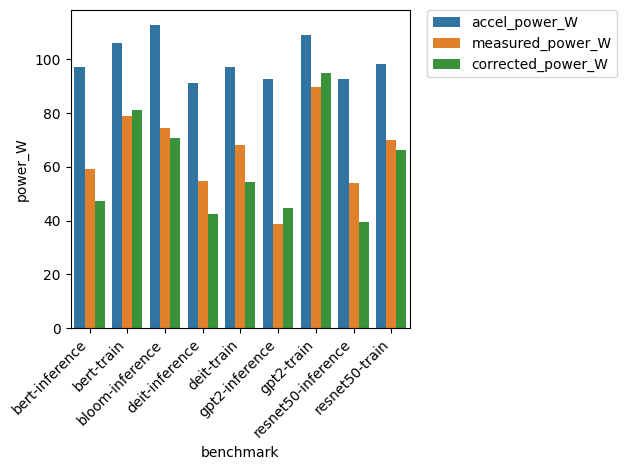

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(
    correct_df.select("benchmark", "accel_power_W", "measured_power_W", "corrected_power_W")
    .sort("benchmark")
    .unpivot(index="benchmark", value_name="power_W", variable_name="type"),
    x="benchmark", y="power_W", hue="type"
)
plt.xticks(rotation=45, ha='right')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.) 
plt.tight_layout()
plt.savefig("power.png")

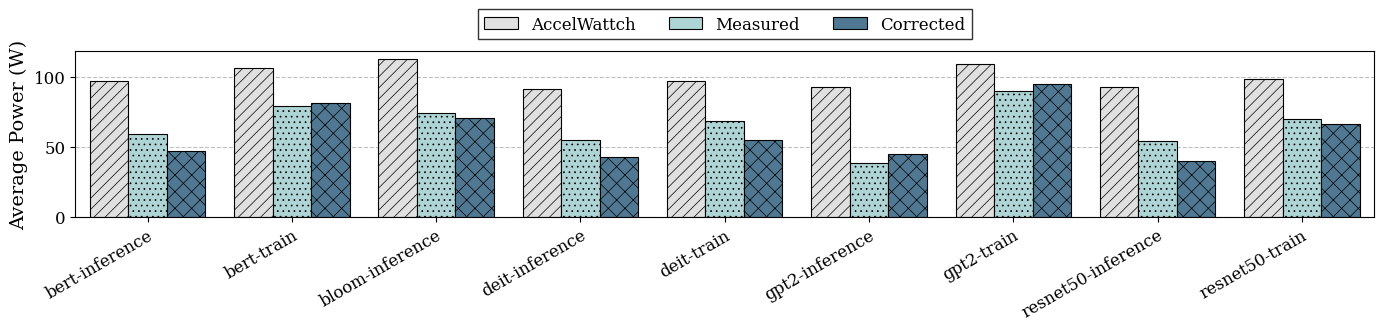

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
import polars as pl

# --- 1. WIDE FIGURE CONFIGURATION ---
# Width of ~7 inches is standard for 2-column papers (spanning both columns).
# We use a slightly larger size (14x3.5) so it scales down crisply.
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif"],
    "font.size": 12,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "figure.figsize": (14, 3.5), # Wide aspect ratio
    "hatch.linewidth": 0.5       # Thinner hatch lines for elegance
})

# --- 2. DATA PREPARATION ---
plot_df = (
    correct_df.select("benchmark", "accel_power_W", "measured_power_W", "corrected_power_W")
    .sort("benchmark")
    .rename({
        "accel_power_W": "AccelWattch",
        "measured_power_W": "Measured",
        "corrected_power_W": "Corrected"
    })
    .unpivot(index="benchmark", value_name="power_W", variable_name="Type")
    .to_pandas()
)

# --- 3. PLOTTING ---
fig, ax = plt.subplots()

# Use a grayscale/muted palette which prints well in black & white papers
# Colors: Light Grey, Light Blue, Dark Blue/Slate
colors = ["#e0e0e0", "#a8dadc", "#457b9d"] 

bar = sns.barplot(
    data=plot_df, 
    x="benchmark", 
    y="power_W", 
    hue="Type", 
    ax=ax, 
    palette=colors,
    edgecolor="black", 
    linewidth=0.8,
    width=0.8
)

# --- 4. APPLY HATCHING (3 Patterns) ---
# Since we have 3 bars per group, we need 3 distinct patterns
# 1. Accelerator: Diagonal lines (//)
# 2. Measured: Dots (..)
# 3. Corrected: Crosshatch (xx) or darker diagonal (\\)
hatches = ['///', '...', 'xx'] 

for i, container in enumerate(ax.containers):
    # Loop through each bar in the container
    for patch in container:
        # Set pattern based on the container index (0, 1, or 2)
        patch.set_hatch(hatches[i % len(hatches)])

# --- 5. LAYOUT & STYLING ---
ax.grid(which='major', axis='y', linestyle='--', color='gray', alpha=0.5, zorder=0)
ax.set_axisbelow(True)

ax.set_xlabel("", fontsize=1)
ax.set_ylabel("Average Power (W)", fontsize=14)

# Rotate x-ticks slightly for readability
plt.xticks(rotation=30, ha='right', rotation_mode="anchor")

# Legend: Centered above the plot, horizontal
ax.legend(
    loc='lower center', 
    bbox_to_anchor=(0.5, 1.02), 
    ncol=3, # 3 columns for 3 items
    frameon=True, 
    edgecolor="black",
    fancybox=False
)

plt.tight_layout()

# Save
plt.savefig("power.pdf", dpi=300, bbox_inches='tight')
plt.show()

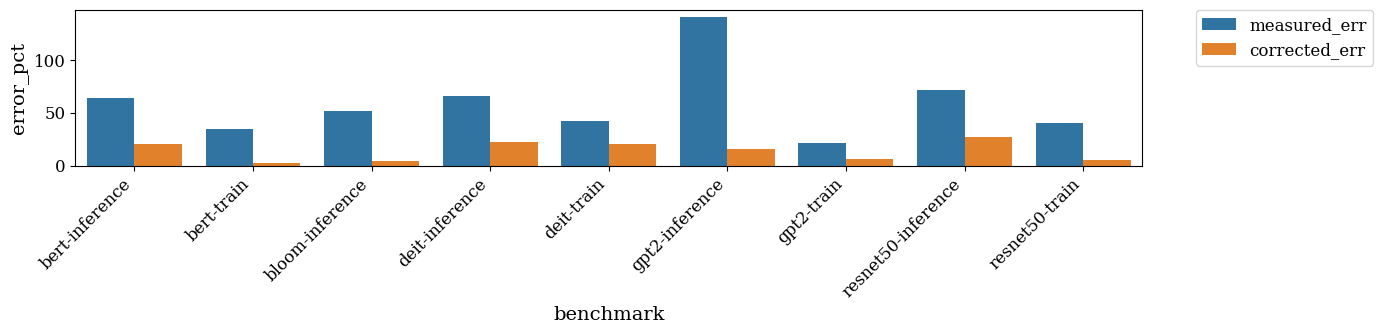

In [35]:
sns.barplot(
    correct_df.select("benchmark", "accel_power_W", "measured_power_W", "corrected_power_W")
    .sort("benchmark")
    .select(
        "benchmark",
        measured_err = (pl.col("accel_power_W")/pl.col("measured_power_W") - 1) * 100,
        corrected_err = abs(pl.col("corrected_power_W")/pl.col("measured_power_W") - 1) * 100,
    )
    .unpivot(index="benchmark", value_name="error_pct", variable_name="type"),
    x="benchmark", y="error_pct", hue="type"
)
plt.xticks(rotation=45, ha='right')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.) 
plt.tight_layout()
plt.savefig("error.png")

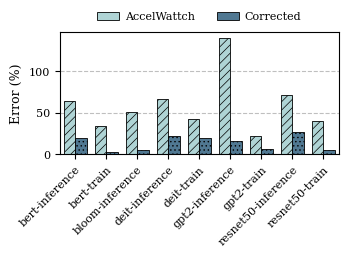

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns
import polars as pl

# --- 1. SINGLE-COLUMN STYLE CONFIGURATION ---
# A typical single column is ~3.3 to 3.5 inches wide.
# We make the height about 2.5 inches for a good aspect ratio.
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif"],
    # Reduce font sizes for the smaller plot
    "font.size": 8,
    "axes.labelsize": 9,
    "axes.titlesize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "figure.figsize": (3.4, 2.5), # <--- KEY CHANGE: Width ~3.4 inches
    "figure.autolayout": True # Helps with tight layouts automatically
})

# --- 2. DATA PREPARATION (Same as before) ---
# Assuming 'correct_df' is your existing Polars DataFrame
plot_df = (
    correct_df.select("benchmark", "accel_power_W", "measured_power_W", "corrected_power_W")
    .sort("benchmark")
    .select(
        pl.col("benchmark"),
        AccelWattch = (pl.col("accel_power_W")/pl.col("measured_power_W") - 1) * 100,
        Corrected = (pl.col("corrected_power_W")/pl.col("measured_power_W") - 1).abs() * 100,
    )
    .unpivot(index="benchmark", value_name="error_pct", variable_name="Type")
    .to_pandas()
)

# --- 3. PLOTTING ---
fig, ax = plt.subplots()

colors = ["#a8dadc", "#457b9d"]

# Create the bar plot with slightly thinner bars and lines for the smaller scale
bar = sns.barplot(
    data=plot_df, 
    x="benchmark", 
    y="error_pct", 
    hue="Type", 
    ax=ax, 
    palette=colors,
    edgecolor="black", 
    linewidth=0.6, # Slightly thinner line
    width=0.75
)

# --- 4. APPLY HATCHING ---
# Using slightly denser patterns for smaller bars can look better
hatches = ['////', '....'] 
for i, container in enumerate(ax.containers):
    for patch in container:
        patch.set_hatch(hatches[i % len(hatches)])

# --- 5. FINE TUNING LAYOUT ---
ax.grid(which='major', axis='y', linestyle='--', color='gray', alpha=0.5, zorder=0)
ax.set_axisbelow(True)

ax.set_xlabel("", fontsize=1) # Basically hide x-label space
ax.set_ylabel("Error (%)")

# Rotate x-ticks more sharply to fit in the narrow space
plt.xticks(rotation=45, ha='right', rotation_mode="anchor")

# Place legend inside the plot or just above to save vertical space.
# (0.5, 1.05) puts it just above the top border.
ax.legend(
    loc='lower center', 
    bbox_to_anchor=(0.5, 1.02), 
    ncol=2, 
    frameon=False, # Removing frame saves visual clutter in small plots
    borderpad=0.2,
    handletextpad=0.5
)

# Important for single-column to remove excess whitespace
plt.tight_layout(pad=0.5)

# Save with high DPI
plt.savefig("error.pdf", dpi=300)
plt.show()

In [37]:
FREQ_MHZ = 1132 

final_df = (
    comp_df.join(idle_df, on="benchmark", how="inner")
    .with_columns([
        # Time (us) = Cycles / (Cycles/us)
        (pl.col("cycles") / FREQ_MHZ).alias("active_time_us"),
    ])
    .with_columns([
        # Energy (uJ) = Power (W) * Time (us)
        # (Watts * Microseconds = Microjoules)
        (pl.col("accel_power_W") * pl.col("active_time_us")).alias("active_energy_uJ")
    ])
    
    .select([
        pl.col("benchmark"),
        pl.col("measure_power_W"),
        pl.col("accel_power_W").alias("old_active_power_W"),
        
        # Corrected Power = (Active Energy + Idle Energy) / (Active Time + Idle Time)
        (
            (pl.col("active_energy_uJ") + pl.col("idle_energy_uJ")) / 
            (pl.col("active_time_us") + pl.col("idle_time_us"))
        ).alias("corrected_power_W")
    ])
)

final_df

ColumnNotFoundError: unable to find column "cycles"; valid columns: ["benchmark", "accel_power_W", "accel_time_us", "measured_power_W", "measured_time_us", "idle_time_us", "constant_power_W", "idle_energy_uJ"]